In [1]:
import logging
import os

import xarray as xr
import numpy as np
import pcraster as pcr
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import geopandas as gpd
import resevoir_functions_fixed as rf

logging.basicConfig(level=logging.INFO, format='%(asctime)s %(levelname)s %(message)s')
logger = logging.getLogger(__name__)

In [2]:
def estimate_discharge_for_environmental_flow(self, channelStorage):
    # z-score for 90th percentile; sets the environmental flow threshold
    z_score = 1.2816

    # Long-term variance of discharge using an online Welford algorithm
    varDischarge = self.m2tDischarge / \
                   pcr.max(1.,
                   pcr.min(self.maxTimestepsToAvgDischargeLong, self.timestepsToAvgDischarge) - 1.)
    stdDischarge = pcr.max(varDischarge**0.5, 0.0)

    # Floor at 10% of avg discharge to prevent flip-flop near the threshold
    minDischargeForEnvironmentalFlow = pcr.max(0.0, self.avgDischarge - z_score * stdDischarge)
    factor = 0.10
    minDischargeForEnvironmentalFlow = pcr.max(factor * self.avgDischarge, minDischargeForEnvironmentalFlow)
    minDischargeForEnvironmentalFlow = pcr.max(0.0, minDischargeForEnvironmentalFlow)

    return minDischargeForEnvironmentalFlow

#This function is most likely redundant as we have the net env flow from the netCDF files.

In [3]:
#loading data
def load_data(file_path):
    try:
        data = xr.open_dataset(file_path)
        logger.info(f"Data loaded successfully from {file_path}")
        return data
    except Exception as e:
        logger.error(f"Error loading data from {file_path}: {e}")
        return None

file_path = os.path.join(os.getcwd(), 'Data', 'POINTDATA') + os.sep

# ── Dam selection ─────────────────────────────────────────────────────────────
# Change dam_id here to run a different reservoir.
# ID must exist in Data/RF/random_forest_inputs_correct.csv (metadata + capacity)
# and in Data/RF/geodar_hydrolakes.csv (coordinates).
dam_id = 111866

# Look up lat/lon and capacity from metadata files
_meta    = pd.read_csv(os.path.join('Data', 'RF', 'random_forest_inputs_correct.csv'))
_geo     = pd.read_csv(os.path.join('Data', 'RF', 'geodar_hydrolakes.csv'))

_dam_meta = _meta[_meta['hydrolakes'] == dam_id]
_dam_geo  = _geo[_geo['Hylak_id'] == dam_id]

if len(_dam_meta) == 0:
    raise ValueError(f"dam_id {dam_id} not found in random_forest_inputs_correct.csv")
if len(_dam_geo) == 0:
    raise ValueError(f"dam_id {dam_id} not found in geodar_hydrolakes.csv")

latitude  = float(_dam_geo['Pour_lat'].iloc[0])
longitude = float(_dam_geo['Pour_long'].iloc[0])
capacity   = float(_dam_meta['cap'].iloc[0]) * 1e6  # CSV stores capacity in million m³

logger.info("Dam %s: lat=%.4f, lon=%.4f, capacity=%.1f m3", dam_id, latitude, longitude, capacity)

# Monthly averages; daily resolution can be re-run for a select region
discharge = load_data(file_path + "sos_resout_final_monthAvg_output.nc").sel(lat=latitude, lon=longitude, method='nearest').to_dataframe().reset_index().drop(columns={'lon', 'lat'})
inflow = load_data(file_path + "soswaterInflow_annuaTot_output.nc").sel(lat=latitude, lon=longitude, method='nearest').to_dataframe().reset_index().drop(columns={'lon', 'lat'})
env_flow = load_data(file_path + 'soswater_env_flow_monthTot_output.nc').sel(lat=latitude, lon=longitude, method='nearest').to_dataframe().reset_index().drop(columns={'lon', 'lat'})
Storage_validation = load_data(file_path + 'sosStor_check_dailyTot_output.nc').sel(lat=latitude, lon=longitude, method='nearest').to_dataframe().reset_index().drop(columns={'lon', 'lat'})

# sosreduction_demand_*_output.nc files are corrupt: they contain storage values instead of
# actual demand. We reconstruct demand by summing the five sector-specific monthly withdrawal
# files that PCR-GLOBWB exports separately.
#
# Unit pipeline:
#   monthTot files → m depth (sum of daily m/day values over the month)
#   × cell_area_m2 → m³/month
#
# Cell area varies with latitude on a regular lat/lon grid (5 arcmin ≈ 0.0833°).
cell_area_m2 = (5/60 * np.pi/180)**2 * 6_371_000**2 * np.cos(np.radians(latitude))

# The five sectors that make up total water demand on the reservoir
withdrawal_files = {
    'domestic':     'domesticWaterWithdrawal_monthTot_output.nc',
    'industry':     'industryWaterWithdrawal_monthTot_output.nc',
    'irr_nonpaddy': 'irrNonPaddyWaterWithdrawal_monthTot_output.nc',
    'irr_paddy':    'irrPaddyWaterWithdrawal_monthTot_output.nc',
    'livestock':    'livestockWaterWithdrawal_monthTot_output.nc',
}

# Load each sector at the dam grid cell and rename its variable column to the sector name
demand_parts = []
for sector, fname in withdrawal_files.items():
    df_part = load_data(file_path + fname).sel(lat=latitude, lon=longitude, method='nearest').to_dataframe().reset_index().drop(columns=['lat', 'lon'])
    df_part = df_part.rename(columns={df_part.columns[1]: sector})
    demand_parts.append(df_part)

# Merge all sectors on time, then sum and convert to m³/month
demand_tot = demand_parts[0].copy()
for df_part in demand_parts[1:]:
    demand_tot = pd.merge(demand_tot, df_part, on='time')

demand_tot['demand_m3'] = demand_tot[list(withdrawal_files.keys())].sum(axis=1) * cell_area_m2
demand_tot = demand_tot[['time', 'demand_m3']]

# Calculate the number of days in each month and the monthly inflow based on the daily inflow
inflow['year'] = inflow['time'].dt.year

output = pd.merge(demand_tot, discharge, on='time')
output = pd.merge(output, Storage_validation, on='time')
output = pd.merge(output, env_flow, on='time')

output['year'] = output['time'].dt.year
output = pd.merge(output, inflow[['year', 'soswater_inflow']], on='year')

output['days_in_month'] = output['time'].dt.days_in_month
output['days_in_year'] = output['time'].dt.is_leap_year.map({True: 366, False: 365})
output['inflow_monthly'] = (output['soswater_inflow'] / output['days_in_year']) * output['days_in_month']
output['modelled_storage'] = 0.0
output['model_release'] = 0.0
output['flood'] = 0.0
output['conservation'] = 0.0
output['model_current_storage'] = 0.0
output['reduction_factor_model'] = 0.0
output['day'] = range(0, len(output))

df = output.copy()
avg_inflow = inflow['soswater_inflow'].mean()

#import flood and conservation bounds
rf_dir = os.path.join('Data', 'POINTDATA', '10_param_RF_bounds_final')

bounds = {} #fractions of capacity
for fname in os.listdir(rf_dir):
    if fname.endswith('.nc'):
        ds = xr.open_dataset(os.path.join(rf_dir, fname))
        row = ds.sel(latitude=latitude, longitude=longitude, method='nearest')
        key = fname.replace('.nc', '')  # e.g. "2000-3-15"
        bounds[key] = (float(row['flood'])/100, float(row['conservation'])/100)


2026-05-19 12:45:51,488 INFO Dam 111866: lat=41.1322, lon=-122.0731, capacity=43500000.0 m3
2026-05-19 12:45:51,898 INFO Data loaded successfully from c:\Users\dlp96\Documents\GitHub\resevoir_study\Data\POINTDATA\sos_resout_final_monthAvg_output.nc
2026-05-19 12:45:51,947 INFO Data loaded successfully from c:\Users\dlp96\Documents\GitHub\resevoir_study\Data\POINTDATA\soswaterInflow_annuaTot_output.nc
2026-05-19 12:45:51,957 INFO Data loaded successfully from c:\Users\dlp96\Documents\GitHub\resevoir_study\Data\POINTDATA\soswater_env_flow_monthTot_output.nc
2026-05-19 12:45:52,083 INFO Data loaded successfully from c:\Users\dlp96\Documents\GitHub\resevoir_study\Data\POINTDATA\sosStor_check_dailyTot_output.nc
2026-05-19 12:45:53,390 INFO Data loaded successfully from c:\Users\dlp96\Documents\GitHub\resevoir_study\Data\POINTDATA\domesticWaterWithdrawal_monthTot_output.nc
2026-05-19 12:45:53,442 INFO Data loaded successfully from c:\Users\dlp96\Documents\GitHub\resevoir_study\Data\POINTDATA

In [4]:
df

,time,demand_m3,sos_reservoir_outflow_end,sos_storage_check,soswater_env_flow,year,soswater_inflow,days_in_month,days_in_year,inflow_monthly,modelled_storage,model_release,flood,conservation,model_current_storage,reduction_factor_model,day
0,1979-01-31,16738.753906,9.738359e+05,43500000.0,104.331367,1979,199157408.0,31,365,1.691474e+07,0.0,0.0,0.0,0.0,0.0,0.0,0
1,1979-02-28,16850.867188,1.333302e+06,43500000.0,95.698196,1979,199157408.0,28,365,1.527783e+07,0.0,0.0,0.0,0.0,0.0,0.0,1
2,1979-03-31,16886.748047,1.138932e+06,43500000.0,109.436768,1979,199157408.0,31,365,1.691474e+07,0.0,0.0,0.0,0.0,0.0,0.0,2
3,1979-04-30,17007.830078,9.965820e+05,43500000.0,108.142525,1979,199157408.0,30,365,1.636910e+07,0.0,0.0,0.0,0.0,0.0,0.0,3
4,1979-05-31,17218.613281,5.588231e+05,43500000.0,112.566414,1979,199157408.0,31,365,1.691474e+07,0.0,0.0,0.0,0.0,0.0,0.0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
535,2023-08-31,30074.216797,1.984420e+05,43500000.0,116.750183,2023,225386512.0,31,365,1.914242e+07,0.0,0.0,0.0,0.0,0.0,0.0,535
536,2023-09-30,29750.437500,9.075533e+03,43500000.0,111.231949,2023,225386512.0,30,365,1.852492e+07,0.0,0.0,0.0,0.0,0.0,0.0,536
537,2023-10-31,29245.718750,2.322999e+04,43500000.0,113.145767,2023,225386512.0,31,365,1.914242e+07,0.0,0.0,0.0,0.0,0.0,0.0,537
538,2023-11-30,28702.904297,0.000000e+00,43500000.0,107.744225,2023,225386512.0,30,365,1.852492e+07,0.0,0.0,0.0,0.0,0.0,0.0,538


In [18]:
df_simulation = df.copy()

# FIX: storage_capacity defined once outside the loop (was recalculated 540x via .max())
storage_capacity = capacity
avg_outflow_m3 = (discharge['sos_reservoir_outflow_end'] * output['days_in_month'] * 86400).mean() #the values are actually probably already in m^3/month so this is probably not needed.
avg_discharge_m3 = discharge['sos_reservoir_outflow_end'].mean()

for t, row in df_simulation.iterrows():

    key = f"2000-{row['time'].month}-{row['time'].day}"
    flood_frac, conservation_frac = bounds[key]  # get the flood and conservation bounds

    max_storage = flood_frac * capacity
    min_storage = conservation_frac * capacity

    if t == 0:  # initial conditions
        current_storage = storage_capacity / 2
    else:
        current_storage = df_simulation.loc[t - 1, 'modelled_storage']

    # FIX: carry forward previous release so irrigation/hydropower logic sees a non-zero
    # current_release and can branch correctly (was always 0 by default)
    prev_release = df_simulation.loc[t - 1, 'model_release'] if t > 0 else 0.0

    logger.debug('flood and conservation values %s %s', max_storage, min_storage)

    # FIX: convert discharge from m³/s (monthAvg) to m³/month so it is on the same
    # unit basis as inflow_monthly, demand_m3, and modelled_storage
    # avg_outflow_m3 = row['sos_reservoir_outflow_end'] * row['days_in_month'] * 86400

    reduction_factor_val = rf.reduction_factor(
        current_storage=current_storage, min_storage=min_storage, max_storage=max_storage
    )
    release = rf.starfit_release(
        current_storage=current_storage,
        storage_capacity=storage_capacity,
        max_storage=max_storage,
        min_storage=min_storage,
        avg_outflow=row['sos_reservoir_outflow_end'],
        env_flow=row['soswater_env_flow'],
        demand=row['demand_m3'],
        avg_discharge=avg_discharge_m3,
        current_release=prev_release,
        use='irrigation',
    )

    df_simulation.loc[t, 'model_release'] = release
    # FIX: write the diagnostic columns that were computed but never stored
    df_simulation.loc[t, 'flood'] = max_storage
    df_simulation.loc[t, 'conservation'] = min_storage
    df_simulation.loc[t, 'model_current_storage'] = current_storage
    df_simulation.loc[t, 'reduction_factor_model'] = reduction_factor_val

    new_storage = rf.new_storage(
        release=release,
        current_storage=current_storage,
        inflow=row['inflow_monthly'],
        # FIX: pass capacity so excess above full pool is spilled rather than accumulated
        storage_capacity=storage_capacity,
    )
    df_simulation.loc[t, 'modelled_storage'] = new_storage


TypeError: starfit_release() got an unexpected keyword argument 'avg_discharge'

In [16]:
df_simulation

,time,demand_m3,sos_reservoir_outflow_end,sos_storage_check,soswater_env_flow,year,soswater_inflow,days_in_month,days_in_year,inflow_monthly,modelled_storage,model_release,flood,conservation,model_current_storage,reduction_factor_model,day
0,1979-01-31,16738.753906,9.738359e+05,43500000.0,104.331367,1979,199157408.0,31,365,1.691474e+07,3.866463e+07,1.043314e+02,2.652245e+07,2.458018e+07,2.175000e+07,0.0,0
1,1979-02-28,16850.867188,1.333302e+06,43500000.0,95.698196,1979,199157408.0,28,365,1.527783e+07,4.271443e+07,1.122804e+07,2.743660e+07,2.475897e+07,3.866463e+07,1.0,1
2,1979-03-31,16886.748047,1.138932e+06,43500000.0,109.436768,1979,199157408.0,31,365,1.691474e+07,4.350000e+07,1.455036e+07,2.816407e+07,2.447428e+07,4.271443e+07,1.0,2
3,1979-04-30,17007.830078,9.965820e+05,43500000.0,108.142525,1979,199157408.0,30,365,1.636910e+07,4.350000e+07,1.496180e+07,2.853820e+07,2.379134e+07,4.350000e+07,1.0,3
4,1979-05-31,17218.613281,5.588231e+05,43500000.0,112.566414,1979,199157408.0,31,365,1.691474e+07,4.350000e+07,1.511205e+07,2.838795e+07,2.262190e+07,4.350000e+07,1.0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
535,2023-08-31,30074.216797,1.984420e+05,43500000.0,116.750183,2023,225386512.0,31,365,1.914242e+07,4.350000e+07,1.769314e+07,2.580686e+07,2.071269e+07,4.350000e+07,1.0,535
536,2023-09-30,29750.437500,9.075533e+03,43500000.0,111.231949,2023,225386512.0,30,365,1.852492e+07,4.350000e+07,1.842060e+07,2.507940e+07,2.099738e+07,4.350000e+07,1.0,536
537,2023-10-31,29245.718750,2.322999e+04,43500000.0,113.145767,2023,225386512.0,31,365,1.914242e+07,4.350000e+07,1.882087e+07,2.467913e+07,2.189652e+07,4.350000e+07,1.0,537
538,2023-11-30,28702.904297,0.000000e+00,43500000.0,107.744225,2023,225386512.0,30,365,1.852492e+07,4.338042e+07,1.864450e+07,2.485550e+07,2.284977e+07,4.350000e+07,1.0,538


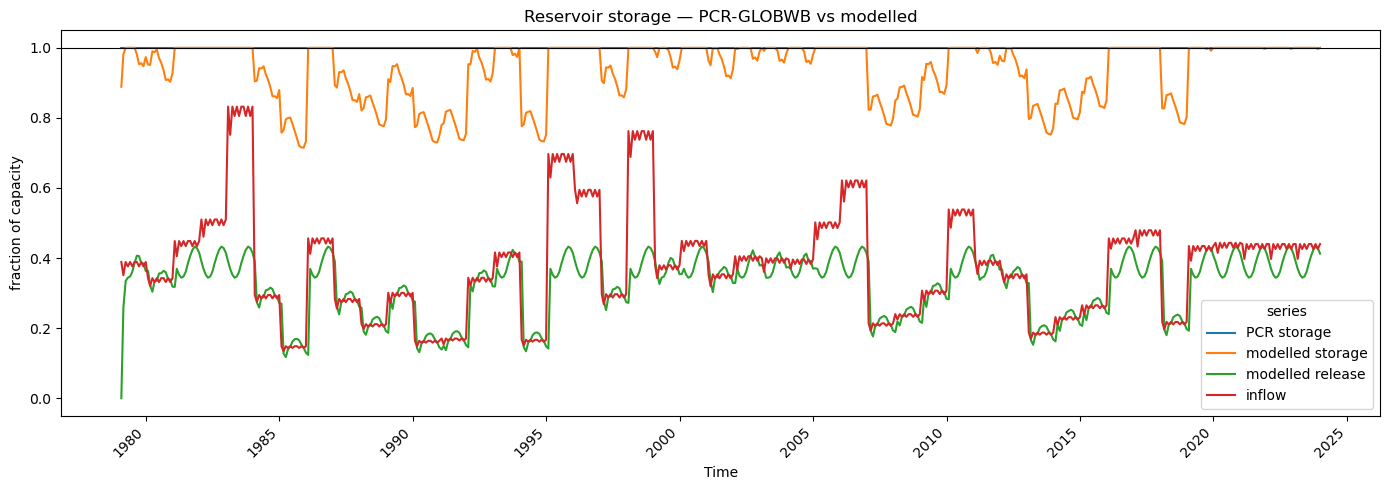

In [17]:
# Normalise storage and release by capacity, then melt to long format for seaborn
plot_df = df_simulation[['time', 'sos_storage_check', 'modelled_storage', 'model_release', 'inflow_monthly']].copy()
plot_df['PCR storage']      = plot_df['sos_storage_check']  / capacity
plot_df['modelled storage'] = plot_df['modelled_storage']   / capacity
plot_df['modelled release'] = plot_df['model_release']      / capacity
plot_df['inflow']           = plot_df['inflow_monthly']     / capacity

plot_long = plot_df.melt(
    id_vars='time',
    value_vars=['PCR storage', 'modelled storage', 'modelled release', 'inflow'],
    var_name='series',
    value_name='fraction of capacity'
)

fig, ax = plt.subplots(figsize=(14, 5))
sns.lineplot(data=plot_long, x='time', y='fraction of capacity', hue='series', ax=ax)
ax.axhline(y=1.0, color='black', linestyle='-', linewidth=0.8, label='full capacity')
ax.set_title('Reservoir storage — PCR-GLOBWB vs modelled')
ax.set_xlabel('Time')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [9]:
print(discharge['sos_reservoir_outflow_end'].describe())
print(avg_outflow_m3)


count    5.400000e+02
mean     5.429267e+05
std      6.214304e+05
min      0.000000e+00
25%      1.479308e+05
50%      3.194471e+05
75%      7.711085e+05
max      5.056630e+06
Name: sos_reservoir_outflow_end, dtype: float64
1418404846706.9336


In [10]:
print(discharge['sos_reservoir_outflow_end'].head(24))

0     9.738359e+05
1     1.333302e+06
2     1.138932e+06
3     9.965820e+05
4     5.588231e+05
5     3.115467e+05
6     3.078080e+05
7     1.724285e+05
8     5.851333e+03
9     1.385338e+05
10    2.930659e+05
11    3.396695e+05
12    1.034130e+06
13    1.636130e+06
14    1.173637e+06
15    9.509419e+05
16    4.047628e+05
17    3.189144e+05
18    3.149975e+05
19    1.400904e+05
20    0.000000e+00
21    2.964262e+04
22    7.819296e+04
23    2.870929e+05
Name: sos_reservoir_outflow_end, dtype: float32


In [11]:
ds_discharge = xr.open_dataset(file_path + 'sos_resout_final_monthAvg_output.nc')
print(ds_discharge.sel(lat=latitude, lon=longitude, method='nearest').lat.values)
print(ds_discharge.sel(lat=latitude, lon=longitude, method='nearest').lon.values)

41.125
-122.041664


In [13]:
print(discharge['sos_reservoir_outflow_end'].mean())  # ~542,000 m³/month


542926.7
